# 5. Redes Neuronales Convolucionales (CNN)

En este notebook aprenderás a construir y entrenar redes convolucionales para clasificación de imágenes, usando TensorFlow/Keras. Se incluye teoría, código, visualizaciones, análisis de hiperparámetros y recomendaciones prácticas.

## Objetivo
- Comprender la teoría y arquitectura de las redes convolucionales (CNN).
- Implementar y entrenar una CNN para clasificación de imágenes.
- Analizar el impacto de los hiperparámetros y visualizar el aprendizaje.
- Visualizar filtros aprendidos para entender qué aprende la red.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado el [notebook 04 (MLP)](./04_redes_neuronales_capa_densa.ipynb).

- Conceptos de redes neuronales, funciones de activación y entrenamiento con Keras.

## 1. Introducción teórica

Una **red neuronal convolucional (CNN)** es un tipo de red diseñada para procesar datos con estructura de grilla, como imágenes. A diferencia de una red densa (MLP), las CNN explotan la estructura espacial de los datos mediante **pesos compartidos** y **conectividad local**.

### ¿Cómo funciona una convolución?

Una capa convolucional aplica un conjunto de **filtros** (kernels) que se deslizan sobre la imagen. Cada filtro produce un **mapa de características** (feature map) que resalta un patrón específico (bordes, texturas, curvas).

```
Imagen entrada        Filtro 3x3          Feature map
┌─────────────┐     ┌─────────┐         ┌──────────┐
│ 0  1  0  1  │  *  │ 1  0 -1 │   →     │ respuesta│
│ 1  1  0  0  │     │ 1  0 -1 │         │ por zona │
│ 0  0  1  1  │     │ 1  0 -1 │         └──────────┘
└─────────────┘     └─────────┘
```

**Parámetros clave de Conv2D:**
- `filters`: cantidad de filtros (patrones a detectar). Más filtros → más capacidad, más cómputo.
- `kernel_size`: tamaño del filtro (3×3 o 5×5 son los más comunes).
- `activation='relu'`: aplica `max(0, x)` — elimina valores negativos y añade no-linealidad.
- `padding='valid'` (defecto): no rellena los bordes → el feature map es más pequeño.
- `padding='same'`: rellena para mantener las dimensiones de salida iguales a la entrada.

### Capas de la arquitectura CNN

| Capa | Función | ¿Por qué? |
|------|---------|-----------|
| `Conv2D` | Detecta patrones locales (bordes, curvas) | Comparte pesos → muchos menos parámetros que Dense |
| `MaxPooling2D` | Reduce dimensiones tomando el máximo en cada ventana | Comprime la representación y da invarianza a pequeñas traslaciones |
| `Flatten` | Convierte el tensor 3D en un vector 1D | Necesario para conectar con capas Dense |
| `Dense` | Combina las características para clasificar | Aprende relaciones globales entre las features extraídas |
| `Dropout` | Apaga neuronas aleatoriamente durante el entrenamiento | Regularización: evita que la red dependa de rutas específicas |

### Flujo de información en una CNN

```
Imagen (28×28×1)
  → Conv2D(32, 3×3) → ReLU  → (26×26×32)   [detecta bordes simples]
  → MaxPooling2D(2×2)        → (13×13×32)   [reduce tamaño]
  → Conv2D(64, 3×3) → ReLU  → (11×11×64)   [detecta formas complejas]
  → MaxPooling2D(2×2)        → (5×5×64)     [reduce tamaño]
  → Flatten                  → (1600,)
  → Dense(64) → ReLU         → (64,)        [combina features]
  → Dropout(0.3)
  → Dense(10) → Softmax      → (10,)        [probabilidad por clase]
```

### ¿Por qué CNN y no MLP para imágenes?

- Una imagen MNIST (28×28) tiene 784 píxeles. Una capa Dense con 128 neuronas usaría **784 × 128 = 100,352 parámetros** solo en la primera capa, sin aprovechar la estructura espacial.
- Con Conv2D(32, 3×3), el número de parámetros es solo **(3×3×1 + 1) × 32 = 320**. La misma red aprende patrones locales en cualquier posición de la imagen gracias al **peso compartido**.

**Ventajas de CNN:**
- Excelentes para imágenes y datos con estructura espacial.
- Muchos menos parámetros que una red densa equivalente.
- Invariantes a traslaciones (el mismo patrón se detecta en cualquier posición).

**Desventajas:**
- Requieren más cómputo y datos que modelos clásicos.
- Arquitectura y ajuste de hiperparámetros más complejos.

## 2. Importación de librerías

**¿Por qué estas librerías?**
- `tensorflow / keras`: framework principal para construir y entrenar la CNN. Keras es la API de alto nivel de TF.
- `numpy`: manipulación de arrays y operaciones numéricas sobre los datos de imagen.
- `matplotlib / seaborn`: visualización de imágenes, curvas de entrenamiento y matrices de confusión.
- `sklearn.metrics`: métricas de evaluación (matriz de confusión, classification report).
- `os / logging`: control del nivel de verbosidad de TensorFlow para evitar logs de XLA/compilador.

**Nota sobre reproducibilidad:**
Fijar `SEED` en `random`, `numpy` y `tf.random` asegura que los pesos iniciales y el shuffling de datos sean iguales en cada ejecución, permitiendo comparar experimentos de forma justa.

In [1]:
# === Reproducibilidad ===
import random
import numpy as np
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# === Suprimir logs de TensorFlow/XLA ANTES de importar TF ===
# TF_CPP_MIN_LOG_LEVEL: 0=INFO, 1=WARNING, 2=ERROR, 3=FATAL
# Con '2' los logs INFO del compilador XLA (dot_merger.cc, etc.) se escapan
# porque usan abseil C++ logging. Con '3' se eliminan todos salvo FATAL.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras

# Segunda capa: suprimir logs a nivel Python (cubre el logger de TF y absl)
import logging
tf.get_logger().setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

tf.random.set_seed(SEED)

sns.set(style="whitegrid")
%matplotlib inline

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.21.0
GPU disponible: True


## 3. Carga y exploración del dataset

Usaremos **MNIST**, uno de los datasets más conocidos en Deep Learning:
- **60,000 imágenes** de entrenamiento y **10,000 de prueba**.
- Cada imagen es de **28×28 píxeles** en escala de grises (1 canal).
- Representa **dígitos escritos a mano** del 0 al 9 (10 clases balanceadas, ~6,000 por clase).

`keras.datasets.mnist.load_data()` descarga y divide los datos automáticamente. Los valores de píxel originales están en el rango `[0, 255]` (uint8).

**¿Qué buscar en la exploración?**
- ¿Las clases están balanceadas? (importante para que el modelo no sesgue hacia clases mayoritarias).
- ¿Las imágenes tienen variabilidad? (rotaciones, grosores de trazo distintos → el modelo debe generalizar).
- ¿Hay dígitos ambiguos? (p.ej. un 4 que parece 9 → errores naturales del modelo).

Shape X_train: (60000, 28, 28), y_train: (60000,)


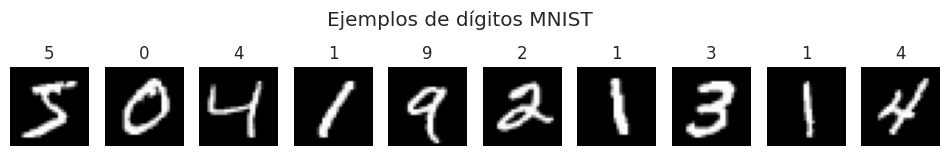

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(f"Shape X_train: {X_train.shape}, y_train: {y_train.shape}")

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"{y_train[i]}")
    ax.axis('off')
plt.suptitle('Ejemplos de dígitos MNIST')
plt.show()

## 4. Preprocesamiento de datos

El preprocesamiento convierte los datos crudos al formato que espera la CNN. Hay tres pasos:

### 4.1 Normalización de píxeles
Los valores de píxel originales van de 0 a 255. Los dividimos por 255 para llevarlos al rango **[0.0, 1.0]**.

**¿Por qué?** Las redes neuronales convergen más rápido y con mayor estabilidad cuando los inputs están en rangos pequeños. Con valores grandes (p.ej. 200), los gradientes pueden explotar o volverse inestables durante el backpropagation.

### 4.2 Dimensión de canal
`Conv2D` espera tensores de forma `(batch, height, width, channels)`. Las imágenes MNIST son en escala de grises (1 canal), pero vienen con forma `(60000, 28, 28)`. Necesitamos agregar la dimensión de canal: `(60000, 28, 28, 1)`.

- Imágenes RGB tendrían `channels=3` (rojo, verde, azul).
- `np.expand_dims(..., -1)` agrega la dimensión al final.

### 4.3 One-hot encoding de las etiquetas
Las etiquetas originales son enteros `[0, 1, 2, ..., 9]`. La función de pérdida `categorical_crossentropy` requiere vectores binarios:

```
y = 3  →  y_cat = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y = 7  →  y_cat = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
```

Esto permite que la capa `Softmax` final produzca una distribución de probabilidad sobre las 10 clases y se calcule el error correctamente.

> **Alternativa:** Si usas `sparse_categorical_crossentropy` como función de pérdida, no necesitas one-hot encoding y las etiquetas pueden quedar como enteros.

In [3]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = np.expand_dims(X_train, -1)  # (60000, 28, 28, 1)
X_test = np.expand_dims(X_test, -1)

num_classes = len(np.unique(y_train))
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"Shape X_train: {X_train.shape}, y_train_cat: {y_train_cat.shape}")

Shape X_train: (60000, 28, 28, 1), y_train_cat: (60000, 10)


## 5. Construcción y entrenamiento de la CNN

### Decisiones de arquitectura

**¿Por qué 2 bloques Conv2D + MaxPooling?**
Apilar bloques permite aprender características de complejidad creciente:
- **Bloque 1 (32 filtros):** detecta bordes horizontales, verticales y diagonales simples.
- **Bloque 2 (64 filtros):** combina los bordes del bloque 1 para detectar curvas, esquinas y formas más complejas.

**¿Por qué `batch_size=64`?**
El batch size define cuántas imágenes se procesan antes de actualizar los pesos. Un batch de 64 es un buen equilibrio entre:
- Batch muy pequeño (p.ej. 1): actualizaciones ruidosas pero mayor regularización implícita.
- Batch muy grande (p.ej. 512): actualizaciones estables pero puede converger a mínimos peores y usar más memoria.

**¿Por qué `validation_split=0.2`?**
Reserva el 20% de los datos de entrenamiento para monitorear el desempeño en datos no vistos durante el entrenamiento. Esto permite detectar sobreajuste (cuando `val_accuracy` deja de mejorar mientras `train_accuracy` sigue subiendo).

**Sobre el compilador:**
- `optimizer='adam'`: ajusta la tasa de aprendizaje automáticamente para cada parámetro. Es el optimizador más robusto para empezar.
- `loss='categorical_crossentropy'`: mide qué tan lejos está la distribución predicha de la distribución real (one-hot).
- `metrics=['accuracy']`: métrica adicional para monitorear; no afecta el entrenamiento.

In [4]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),          # entrada: imagen 28x28 en escala de grises

    # Bloque 1: detecta patrones simples (bordes, gradientes)
    # Salida: (26, 26, 32) — 32 mapas de características, tamaño reducido por válida convolución
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),              # → (13, 13, 32) — reduce a la mitad

    # Bloque 2: detecta patrones más complejos (curvas, formas)
    # Más filtros (64) porque hay más combinaciones posibles de patrones del bloque anterior
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),              # → (5, 5, 64)

    # Transición a clasificación
    keras.layers.Flatten(),                         # → (1600,) — aplanamos para la capa densa
    keras.layers.Dense(64, activation='relu'),      # aprende combinaciones globales de features
    keras.layers.Dropout(0.3),                      # apaga 30% de neuronas al azar → regularización
    keras.layers.Dense(num_classes, activation='softmax')  # 10 salidas, suma = 1 (probabilidades)
])

model.compile(
    optimizer='adam',                      # Adam: tasa de aprendizaje adaptativa por parámetro
    loss='categorical_crossentropy',       # pérdida estándar para clasificación multiclase
    metrics=['accuracy']
)

model.summary()  # muestra arquitectura y número de parámetros por capa

history = model.fit(
    X_train, y_train_cat,
    epochs=10,                # número de pasadas completas sobre los datos de entrenamiento
    batch_size=64,            # imágenes por actualización de pesos
    validation_split=0.2,     # 20% de train → validación (no se usa para entrenar, solo monitorear)
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9153 - loss: 0.2811 - val_accuracy: 0.9802 - val_loss: 0.0687
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9713 - loss: 0.0986 - val_accuracy: 0.9854 - val_loss: 0.0521
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9783 - loss: 0.0730 - val_accuracy: 0.9876 - val_loss: 0.0465
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9815 - loss: 0.0602 - val_accuracy: 0.9876 - val_loss: 0.0455
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9850 - loss: 0.0505 - val_accuracy: 0.9893 - val_loss: 0.0392
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9870 - loss: 0.0426 - val_accuracy: 0.9892 - val_loss: 0.0419
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9883 - loss: 0.0375 - val_accuracy: 0.9893 - val_loss: 0.0441
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9898 - loss: 0.0329 - val_accuracy: 0

## 6. Evaluación y visualización de resultados

### ¿Qué métricas analizar?

- **Accuracy global:** porcentaje de imágenes clasificadas correctamente. En MNIST >99% es alcanzable con una CNN bien diseñada.
- **Matriz de confusión:** muestra qué clases se confunden entre sí. Pares comunes: (4↔9), (3↔8), (5↔6).
- **Precision / Recall / F1 por clase:** revela si el modelo es peor en algún dígito específico. Útil si las clases fueran desbalanceadas.

### ¿Cómo interpretar las curvas de entrenamiento?

```
Situación ideal:           Sobreajuste:              Subajuste:
  train ↗  val ↗             train ↗  val ↘ ↘           train ↗ lento
  curvas cercanas            brecha creciente          val ≈ train (ambas bajas)

  → buen balance            → más Dropout, datos,      → arquitectura más grande,
                              EarlyStopping              más épocas, menos regulariz.
```

- Si `val_loss` empieza a **subir** mientras `train_loss` sigue bajando → **sobreajuste**.
- Si ambas curvas son altas y lentas → **subajuste** (modelo insuficientemente expresivo).
- Si hay mucho **ruido** en `val_accuracy` → batch de validación muy pequeño o lr muy alto.

Accuracy (CNN): 0.9914
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


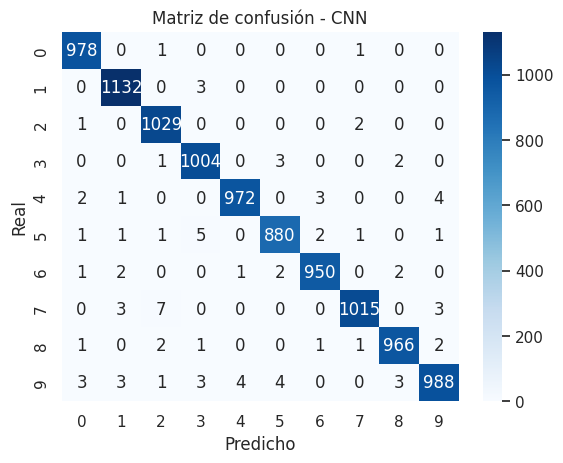

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Accuracy (CNN): {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - CNN')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()
print(classification_report(y_test, y_pred))

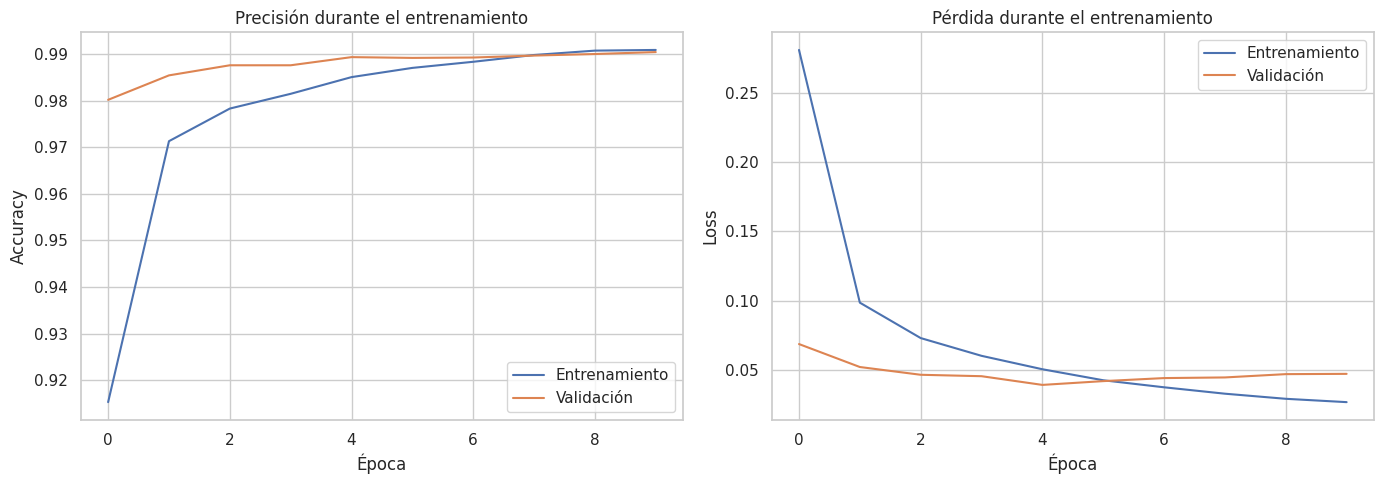

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación')
axes[0].set_title('Precisión durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación')
axes[1].set_title('Pérdida durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Visualización de filtros aprendidos

Los filtros de la primera capa Conv2D son matrices de pesos de 3×3 que la red aprende durante el entrenamiento. Cada filtro detecta un **patrón visual específico**: bordes horizontales, verticales, diagonales, gradientes, etc.

**¿Por qué visualizarlos?**
- Confirmar que la red aprendió representaciones significativas (no ruido aleatorio).
- Entender qué tipo de features extrae cada filtro.
- Diagnosticar problemas: si todos los filtros lucen similares, puede haber un problema de inicialización o la red no está aprendiendo.

**¿Qué esperar?**
En la primera capa de una CNN entrenada en imágenes:
- Filtros que detectan bordes en distintas orientaciones (0°, 45°, 90°, 135°).
- Filtros que responden a cambios de intensidad (blanco→negro o negro→blanco).
- Filtros más abstractos en capas profundas (no visualizables intuitivamente).

> **Nota:** Los filtros de capas profundas son más difíciles de interpretar directamente. Se usan técnicas como **Grad-CAM** o **mapas de activación** para entender qué zonas de la imagen activan cada neurona.

Shape de filtros: (3, 3, 1, 32)


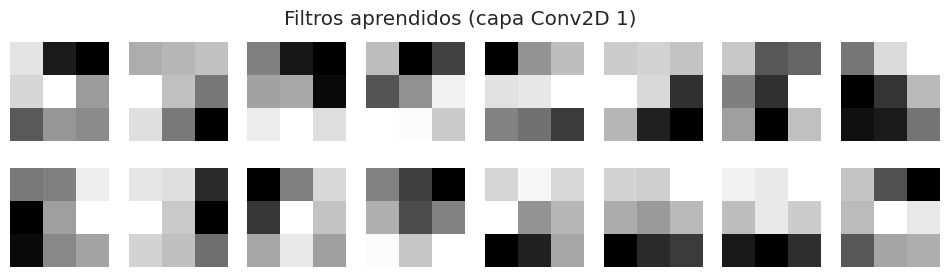

In [7]:
# Obtener los pesos de la primera capa Conv2D
filters, biases = model.layers[0].get_weights()
print(f'Shape de filtros: {filters.shape}')  # (3, 3, 1, 32)

# Visualizar los primeros 16 filtros
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flatten()):
    if i < filters.shape[-1]:
        ax.imshow(filters[:, :, 0, i], cmap='gray')
    ax.axis('off')
plt.suptitle('Filtros aprendidos (capa Conv2D 1)')
plt.show()

## 7. Buenas prácticas: EarlyStopping y Dropout

### Dropout

`Dropout(rate)` apaga aleatoriamente una fracción `rate` de las neuronas durante cada paso de entrenamiento (en inferencia, todas las neuronas están activas y sus salidas se escalan por `1 - rate`).

**¿Por qué funciona?**
Fuerza a la red a aprender representaciones redundantes: ninguna neurona puede depender demasiado de otra para producir la respuesta correcta. Esto equivale a entrenar un ensamble de redes parciales distintas.

- `Dropout(0.3)` → apaga el 30% de neuronas. Regularización moderada.
- `Dropout(0.5)` → apaga el 50%. Más agresivo, útil si hay sobreajuste severo.
- Colocar Dropout **antes de la última capa Dense** es la práctica más común.

### EarlyStopping

`EarlyStopping` detiene el entrenamiento cuando la métrica monitoreada deja de mejorar durante `patience` épocas consecutivas.

**Parámetros clave:**
- `monitor='val_loss'`: observa la pérdida en validación (más confiable que `val_accuracy`).
- `patience=3`: espera 3 épocas sin mejora antes de parar. Un valor bajo para a la red temprano; uno alto permite recuperaciones.
- `restore_best_weights=True`: **crítico** — al finalizar, restaura los pesos de la mejor época, no los de la última.

**¿Por qué es mejor que un número fijo de épocas?**
Con `epochs=20` fijo, el modelo puede sobreajustar después de la época óptima. EarlyStopping detiene exactamente cuando el desempeño en validación es máximo, ahorrando cómputo y evitando el sobreajuste.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Misma arquitectura base pero con Dropout más agresivo (0.5) para comparar
model2 = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),                   # más agresivo que el modelo anterior (0.3)
    keras.layers.Dense(num_classes, activation='softmax')
])

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# EarlyStopping: detiene si val_loss no mejora en 3 épocas consecutivas
# restore_best_weights=True → al parar, recupera los pesos de la mejor época (no la última)
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# Usamos epochs=20 como máximo, pero EarlyStopping puede parar antes
history2 = model2.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=0         # silenciamos la salida por época para mayor claridad
)

best_epoch = np.argmax(history2.history['val_accuracy']) + 1
total_epochs = len(history2.history['val_accuracy'])
print(f"Entrenamiento detenido en época: {total_epochs}")
print(f"Mejor época (max val_accuracy): {best_epoch}")
print(f"Accuracy con EarlyStopping: {model2.evaluate(X_test, y_test_cat, verbose=0)[1]:.4f}")

Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 8.
Entrenamiento detenido en época: 11
Mejor época (max val_accuracy): 8
Accuracy con EarlyStopping: 0.9910


### Recomendaciones prácticas para CNN

| Aspecto | Recomendación |
|---------|---------------|
| **Arquitectura** | Empieza simple, aumenta complejidad si es necesario |
| **Regularización** | Usa `Dropout` y/o `BatchNormalization` |
| **Filtros** | Más filtros en capas profundas (32 → 64 → 128) |
| **Early Stopping** | Monitorea `val_loss` con `patience=3-5` |
| **GPU** | Aprovecha la GPU para acelerar el entrenamiento |
| **Interpretación** | Visualiza filtros y activaciones para entender la red |

## 8. Discusión y Conclusiones

### Resultados obtenidos
- La CNN base (~10 épocas) alcanza >99% de accuracy en MNIST con solo ~93K parámetros.
- EarlyStopping con `patience=3` detiene el entrenamiento en el punto óptimo, evitando sobreajuste sin necesidad de ajustar `epochs` manualmente.
- Los filtros visualizados confirman que la red aprende detectores de bordes y gradientes en la primera capa.

### Conceptos clave de este notebook

| Concepto | Qué aprendimos |
|---------|---------------|
| Convolución | Un filtro deslizante que detecta patrones locales en cualquier posición |
| MaxPooling | Reduce dimensiones y aporta invarianza a pequeñas traslaciones |
| Peso compartido | La misma CNN tiene muchos menos parámetros que un MLP equivalente |
| Dropout | Regularización por apagado aleatorio de neuronas durante el entrenamiento |
| EarlyStopping | Para el entrenamiento automáticamente en la época de mejor generalización |
| One-hot encoding | Formato requerido por `categorical_crossentropy` para clasificación multiclase |

### Próximos pasos
- **Batch Normalization:** acelera la convergencia y permite usar tasas de aprendizaje más altas.
- **Data Augmentation:** aumenta artificialmente el dataset con rotaciones, flips y zooms.
- **Transfer Learning:** reutiliza pesos de redes preentrenadas (ResNet, EfficientNet) para datasets pequeños.
- **RNN/LSTM:** el siguiente notebook aborda secuencias temporales, texto y señales.

## 9. Ejercicios Propuestos

1. **Ejercicio 1:** Cambia el dataset a Fashion MNIST (`keras.datasets.fashion_mnist`). ¿Cómo cambia el accuracy?

2. **Ejercicio 2:** Agrega `BatchNormalization()` después de cada `Conv2D`. ¿Mejora la convergencia?

3. **Ejercicio 3:** Experimenta con Data Augmentation usando `keras.layers.RandomFlip` y `RandomRotation`. ¿Mejora la generalización?

4. **Ejercicio 4 (Avanzado):** Implementa una CNN con 3 bloques convolucionales (Conv2D + BN + MaxPool) y compárala con la arquitectura simple.

## 10. Referencias y Recursos

- [TensorFlow/Keras CNN](https://keras.io/examples/vision/mnist_convnet/)
- [CNN Explainer (Interactivo)](https://poloclub.github.io/cnn-explainer/)
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.*

---

📎 **Notebook anterior:** [04. Redes Neuronales de Capa Densa](./04_redes_neuronales_capa_densa.ipynb)  
📎 **Notebook siguiente:** [06. Redes Recurrentes (RNN/LSTM)](./06_redes_recurrentes_rnn_lstm.ipynb)